In [1]:
%matplotlib ipympl
# from stage 1
import scipy.io as spio
import numpy as np
import scipy.special 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# filter
from scipy.signal import butter,filtfilt

# spike detection
from scipy.signal import find_peaks

# PCA
from sklearn.decomposition import PCA

# classifier
# import all packages needed to run the code
from sklearn import metrics
import scipy.interpolate as interp
from sklearn.model_selection import train_test_split

# Imports
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Filter Functions

In [2]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], analog=False, btype='band')
        y = filtfilt(b, a, data)
        return y

In [3]:
def butter_lowpass_filter(data, cutoff, fs, order=5):
        nyq = 0.5 * fs
        low = cutoff / nyq
        b, a = butter(order, low, analog=False, btype='low')
        y = filtfilt(b, a, data)
        return y

# Load Data

D1: This is a low noise recording that is fully labelled, it has both Index and Class vectors that are
correct. You should use this for training your classifier. <br>
D2: This is a low noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D3: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D4: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>

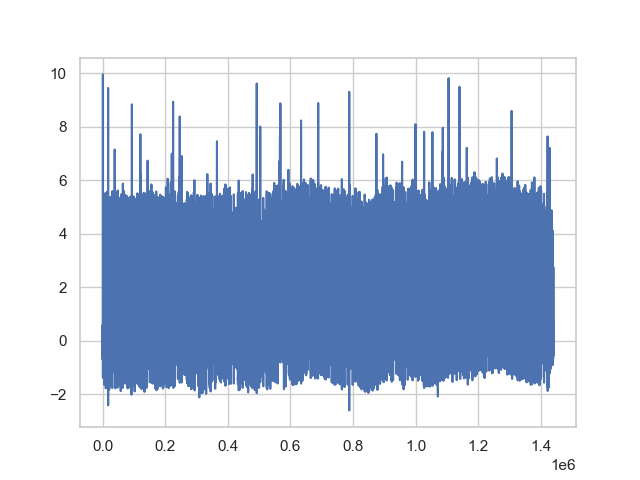

In [4]:
mat = spio.loadmat('D1.mat', squeeze_me=True)
d1 = mat['d'] # Raw time domain recording (1440000 samples), 25 kHz sampling frequency.
Index1 = mat['Index'] # The location in the recording (in samples) of the start of each spike.
Class1 = mat['Class'] # The class (1, 2, 3, 4 or 5), i.e the type of neuron that generated each spike.

plt.figure(0)
plt.plot(d1)

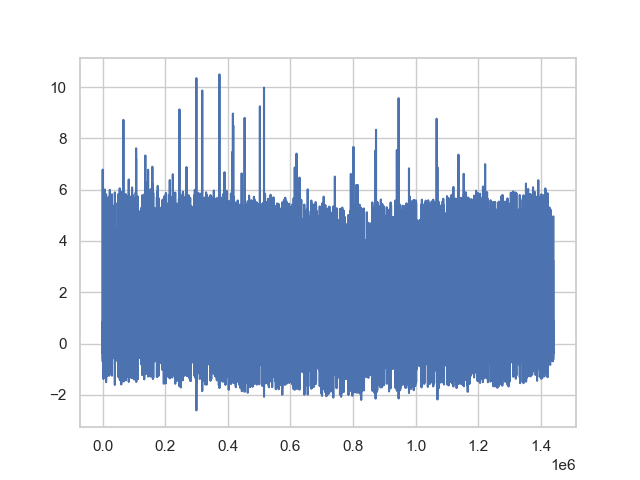

In [5]:
# Load dataset D2 into Python
mat = spio.loadmat('D2.mat', squeeze_me=True)
d2 = mat['d']

plt.figure(1)
plt.plot(d2)

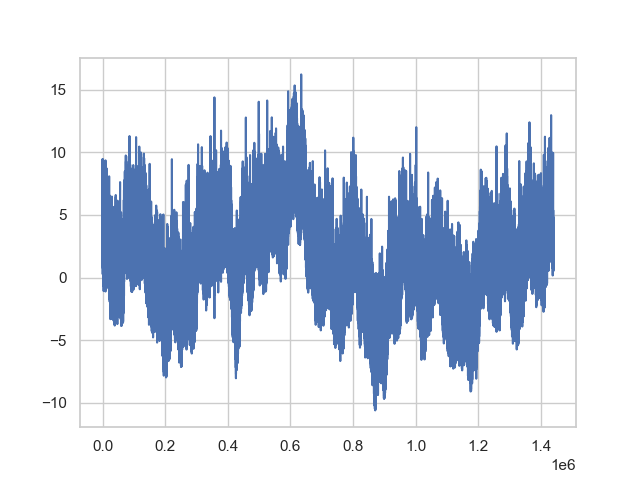

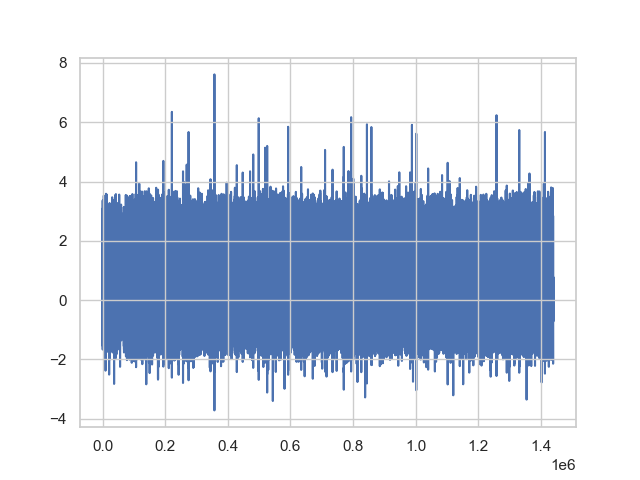

In [6]:
# Load dataset D3 into Python
mat = spio.loadmat('D3.mat', squeeze_me=True)
d3 = mat['d']

plt.figure(2)
plt.plot(d3)

# Filter requirements.
fs = 25000      # sample rate, Hz
order = 1       # sin wave can be approx represented as quadratic
lowcut = 300 # 300
highcut  = 2050 #3000

d3_f = butter_bandpass_filter(d3, lowcut, highcut, fs, order)
plt.figure(3)
plt.plot(d3_f, zorder=-1)

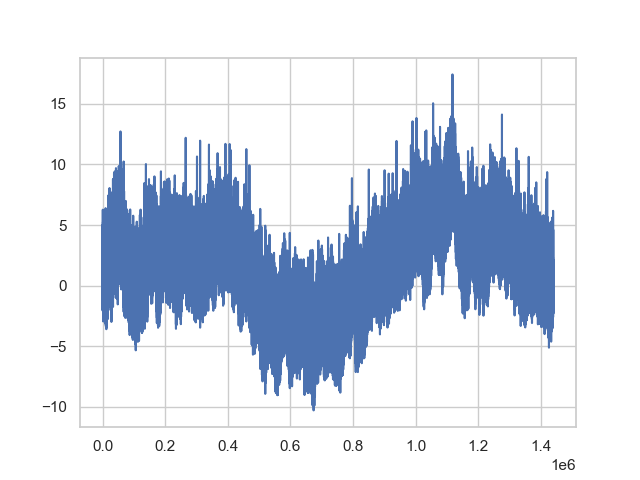

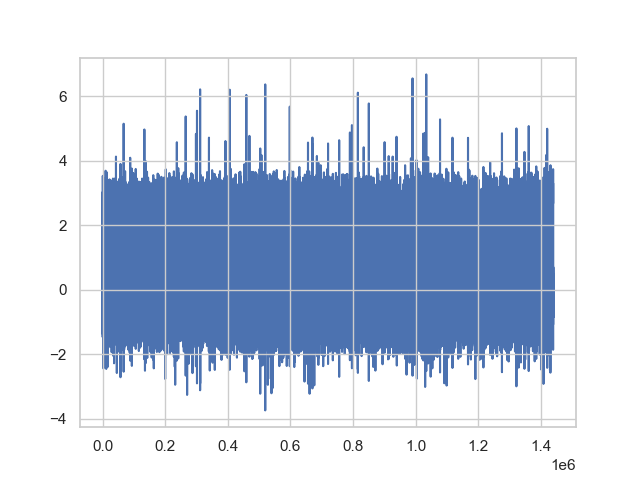

In [7]:
# Load dataset D2 into Python
mat = spio.loadmat('D4.mat', squeeze_me=True)
d4 = mat['d']

plt.figure(4)
plt.plot(d4)

d4_f = butter_bandpass_filter(d4, lowcut, highcut, fs, order)
plt.figure(5)
plt.plot(d4_f, zorder=-1)

# Spike Detection

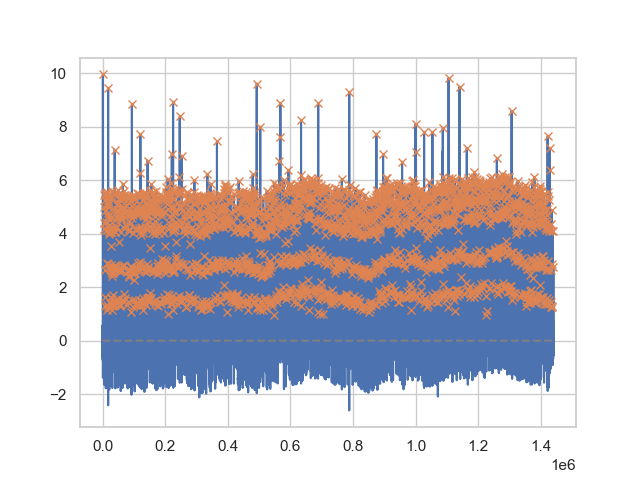

In [8]:
# calculate standard deviation of signal using Donoho's estimation
# std = (np.median(abs(d1 - np.mean(d1))/0.6745))
std = (np.median(abs(d1)/0.6745))

# spike detection threshold
ts = std*3 # some papers use 5*std

peaks1, _ = find_peaks(d1, prominence=1.5, height = ts)
# peaks1, _ = find_peaks(d1, height = ts)

plt.figure(6)
plt.plot(d1)
plt.plot(peaks1, d1[peaks1], "x")
plt.plot(np.zeros_like(d1), "--", color="gray")
plt.show()

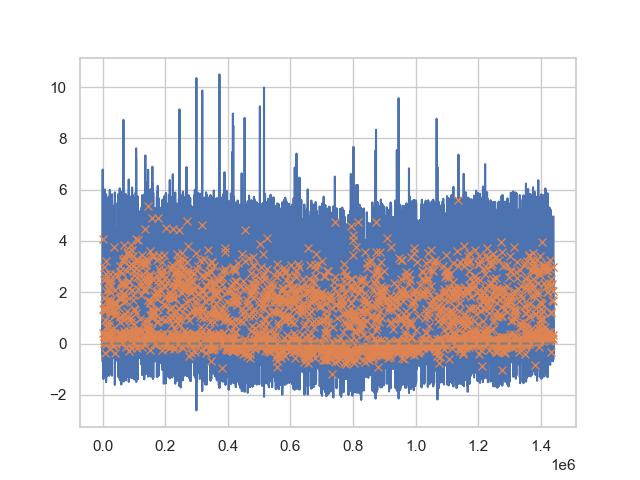

In [9]:
# calculate standard deviation of signal using Donoho's estimation
# std2 = (np.median(abs(d2 - np.mean(d2))/0.6745))
std2 = (np.median(abs(d2)/0.6745))

# spike detection threshold
ts2 = std2*3 # some papers use 5*std

peaks2, _ = find_peaks(d2, prominence=1.5, height=ts2)
# peaks2, _ = find_peaks(d2, height=ts2)

Index2 = peaks2.copy()
for i in range(len(Index2)):
    Index2[i] = Index2[i] - 10

plt.figure(7)
plt.plot(d2)
plt.plot(Index2, d2[Index2], "x")
plt.plot(np.zeros_like(d2), "--", color="gray")
plt.show()    

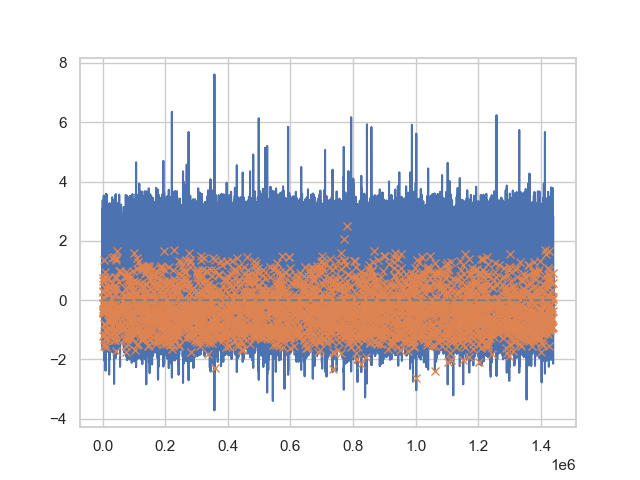

In [10]:
# calculate standard deviation of signal using Donoho's estimation
# std3 = (np.median(abs(d3_f - np.mean(d3_f))/0.6745))
std3 = (np.median(abs(d3_f)/0.6745))
# spike detection threshold
ts3 = std3*3 # some papers use 5*std

peaks3, _ = find_peaks(d3_f, prominence=1.5, height=ts3)
# peaks3, _ = find_peaks(d3_f, height=ts3)

Index3 = peaks3.copy()
for i in range(len(Index3)):
    Index3[i] = Index3[i] - 10

plt.figure(8)
plt.plot(d3_f)
plt.plot(Index3, d3_f[Index3], "x")
plt.plot(np.zeros_like(d3_f), "--", color="gray")
plt.show()  

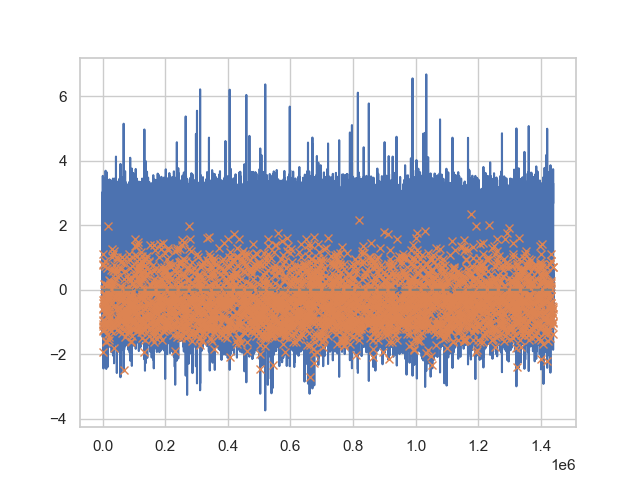

In [11]:
# calculate standard deviation of signal using Donoho's estimation
# std4 = (np.median(abs(d4_f - np.mean(d4_f))/0.6745))
std4 = (np.median(abs(d4_f)/0.6745))

# spike detection threshold
ts4 = std4*3 # some papers use 5*std

peaks4, _ = find_peaks(d4_f, prominence=1.5, height=ts4)
# peaks4, _ = find_peaks(d4_f, height=ts4)

Index4 = peaks4.copy()
for i in range(len(Index4)):
    Index4[i] = Index4[i] - 10

plt.figure(9)
plt.plot(d4_f)
plt.plot(Index4, d4_f[Index4], "x")
plt.plot(np.zeros_like(d4_f), "--", color="gray")
plt.show() 

In [12]:
# Sort index and class
Index1_sorted, Class1_sorted = zip(*sorted(zip(Index1, Class1)))
Index2_sorted = sorted(Index2)
Index3_sorted = sorted(Index3)
Index4_sorted = sorted(Index4)

# Define period of each spike
n_2ms = int((25e3) * 2e-3) # int((25e3)/downsample_factor * 2e-3) # 50 for 25kHz 
if n_2ms%2 != 0:
    n_2ms = n_2ms - 1
n = int(n_2ms/2)
spike = np.zeros([n_2ms,len(Index1)])
spike2 = np.zeros([n_2ms,len(Index2)])
spike3 = np.zeros([n_2ms,len(Index3)])
spike4 = np.zeros([n_2ms,len(Index4)])

# spike = np.zeros([n_2ms+n,len(Index1)])
# spike2 = np.zeros([n_2ms+n,len(Index2)])
# spike3 = np.zeros([n_2ms+n,len(Index3)])
# spike4 = np.zeros([n_2ms+n,len(Index4)])

# Set up arrays for neural network d1
k = 0
for i in range(n,len(d1)-n_2ms):
    if k < len(Index1_sorted) and i == Index1_sorted[k]:
        # spike[:,k] = d1[i-n:i+n_2ms]
        spike[:,k] = d1[i:i+n_2ms]
        k = k + 1

# Set up arrays for neural network d2
k = 0
for i in range(n,len(d2)-n_2ms):
    if k < len(Index2_sorted) and i == Index2_sorted[k]:
        # spike2[:,k] = d1[i-n:i+n_2ms]
        spike2[:,k] = d2[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d3
k = 0
for i in range(n,len(d3_f)-n_2ms):
    if k < len(Index3_sorted) and i == Index3_sorted[k]:
        # spike3[:,k] = d3[i-n:i+n_2ms]
        spike3[:,k] = d3[i:i+n_2ms]
        # spike3[:,k] = d3_f[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d4
k = 0
for i in range(n,len(d4_f)-n_2ms):
    if k < len(Index4_sorted) and i == Index4_sorted[k]:
        # spike4[:,k] = d4[i-n:i+n_2ms]
        spike4[:,k] = d4[i:i+n_2ms]
        # spike4[:,k] = d4_f[i:i+n_2ms]
        k = k + 1 

# Dimension Reduction

In [13]:
# training
x = len(spike[0])
d1_spikes_train = spike[:,0:int(x*0.8)].transpose()
d1_spikes_test = spike[:,int(x*0.8):].transpose()
d2_spikes_test = spike2.transpose()
d3_spikes_test = spike3.transpose()
d4_spikes_test = spike4.transpose()
class1_train = Class1_sorted[0:int(x*0.8)]
class1_test = Class1_sorted[int(x*0.8):]

print(d1_spikes_train.shape)
print(d1_spikes_test.shape)
print(d2_spikes_test.shape)
print(d3_spikes_test.shape)
print(d4_spikes_test.shape)

(2202, 50)
(551, 50)
(2331, 50)
(3374, 50)
(3610, 50)


Total Variance Explained:  0.9360900321849505


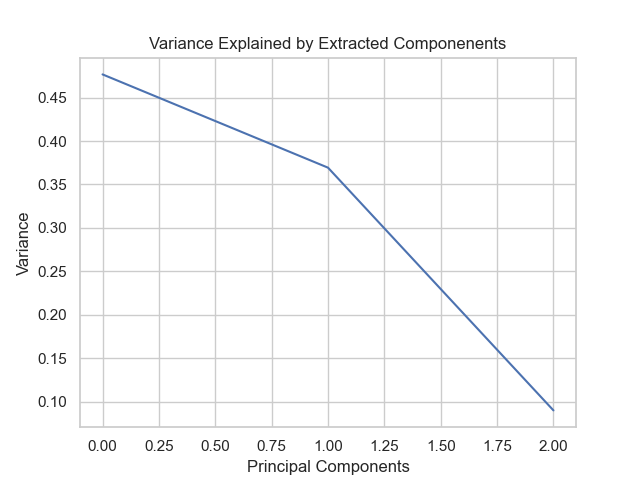

In [14]:
# Select number of components to extract
pca_num = 3
pca = PCA(n_components = pca_num)
# Fit to the training data
pca.fit(d1_spikes_train)

# Determine amount of variance explained by components
print("Total Variance Explained: ", np.sum(pca.explained_variance_ratio_))

# Plot the explained variance
plt.figure(10)
plt.plot(pca.explained_variance_ratio_)
plt.title('Variance Explained by Extracted Componenents')
plt.ylabel('Variance')
plt.xlabel('Principal Components')
plt.show()

# Classifier

Feature shape: (50,)
Epoch 1/32
111/111 [==============================] - 1s 5ms/step - loss: 0.8846 - accuracy: 0.6292 - val_loss: 0.6426 - val_accuracy: 0.7279
Epoch 2/32
111/111 [==============================] - 0s 3ms/step - loss: 0.4961 - accuracy: 0.8393 - val_loss: 0.5523 - val_accuracy: 0.8299
Epoch 3/32
111/111 [==============================] - 0s 3ms/step - loss: 0.3944 - accuracy: 0.8631 - val_loss: 0.4943 - val_accuracy: 0.8662
Epoch 4/32
111/111 [==============================] - 0s 1ms/step - loss: 0.3333 - accuracy: 0.9080 - val_loss: 0.4510 - val_accuracy: 0.9274
Epoch 5/32
111/111 [==============================] - 0s 1ms/step - loss: 0.2947 - accuracy: 0.9290 - val_loss: 0.4388 - val_accuracy: 0.9456
Epoch 6/32
111/111 [==============================] - 0s 1ms/step - loss: 0.2608 - accuracy: 0.9512 - val_loss: 0.4717 - val_accuracy: 0.8753
Epoch 7/32
111/111 [==============================] - 0s 1ms/step - loss: 0.2909 - accuracy: 0.9239 - val_loss: 0.4086 - val_ac

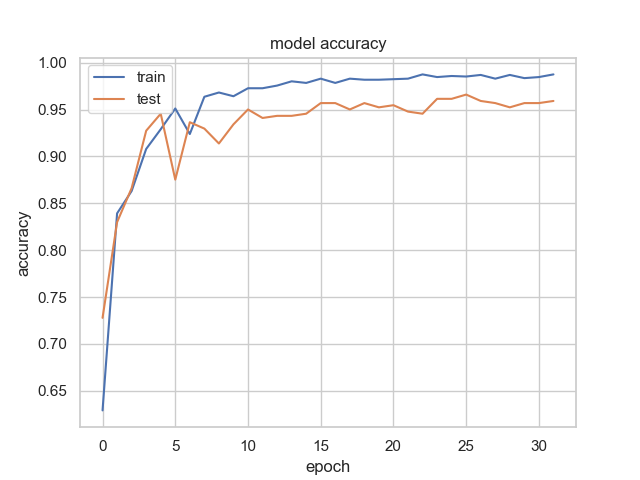

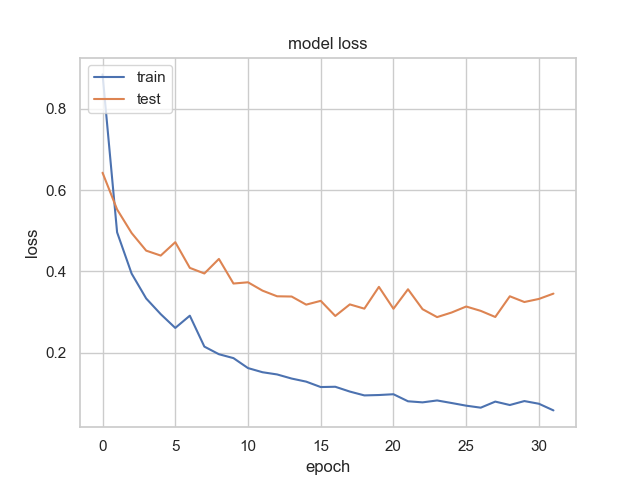

In [15]:
# Configuration options 
feature_vector_length = len(d1_spikes_train[0])
num_classes = 6

# Reshape the data - MLPs do not understand such things as '2D'.
# Reshape to 28 x 28 pixels = 784 features
X_train = d1_spikes_train #.reshape(d1_spikes_train.shape[0], feature_vector_length)
X_test = d1_spikes_test #.reshape(d1_spikes_test.shape[0], feature_vector_length)

# Convert target classes to categorical ones
Y_train = to_categorical(class1_train, num_classes)
Y_test = to_categorical(class1_test, num_classes)

# Set the input shape
input_shape = (feature_vector_length,)
print(f'Feature shape: {input_shape}')

# Create the model
model = Sequential()
model.add(Dense(64, input_shape=input_shape, activation='relu')) #400
model.add(Dense(32, activation='relu')) #100
model.add(Dense(num_classes, activation='softmax'))

# Configure the model and start training
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, Y_train, epochs=32, batch_size=16, verbose=1, validation_split=0.2)

# Test the model after training
test_results = model.evaluate(X_test, Y_test, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]}%')

# summarize history for accuracy
plt.figure(13)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.figure(14)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [16]:
class2_out = model.predict(d2_spikes_test)
Class2 = np.zeros(len(class2_out), dtype=np.int64)
i = 0
for l in class2_out:
    Class2[i] = l.argmax()
    i = i + 1


In [17]:
from scipy.io import savemat

mdic = {"d": d2, "Index": Index2_sorted, "Class": Class2 }
savemat("D2_submit.mat", mdic)

In [18]:
class3_out = model.predict(d3_spikes_test)
Class3 = np.zeros(len(class3_out), dtype=np.int64)
i = 0
for l in class3_out:
    Class3[i] = int(l.argmax())
    i = i + 1

In [19]:
mdic = {"d": d3, "Index": Index3_sorted, "Class": Class3 }
savemat("D3_submit.mat", mdic)

In [20]:
class4_out = model.predict(d4_spikes_test)
Class4 = np.zeros(len(class4_out), dtype=np.int64)
i = 0
for l in class4_out:
    Class4[i] = l.argmax()
    i = i + 1

In [21]:
mdic = {"d": d4, "Index": Index4_sorted, "Class": Class4 }
savemat("D4_submit.mat", mdic)

In [22]:
# Extract the principal components from the training data
train_ext = pca.fit_transform(d1_spikes_train)
# Transform the test data using the same components
test_ext = pca.transform(d1_spikes_test)
test_ext2 = pca.transform(d2_spikes_test)
test_ext3 = pca.transform(d3_spikes_test)
test_ext4 = pca.transform(d4_spikes_test)

In [23]:
# Configuration options 
feature_vector_length = pca_num
num_classes = 6

# Reshape the data 
X_train = train_ext 
X_test = test_ext 

# Convert target classes to categorical ones
Y_train = to_categorical(class1_train, num_classes)
Y_test = to_categorical(class1_test, num_classes)

# Set the input shape
input_shape = (feature_vector_length,)
print(f'Feature shape: {input_shape}')

# Create the model
model = Sequential()
model.add(Dense(200, input_shape=input_shape, activation='relu')) #350
model.add(Dense(10, activation='relu')) #50
model.add(Dense(num_classes, activation='softmax'))

# Configure the model and start training
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, Y_train, epochs=10, batch_size=25, verbose=1, validation_split=0.2)

# Test the model after training
test_results = model.evaluate(X_test, Y_test, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]}%')

Feature shape: (3,)
Epoch 1/10
71/71 [==============================] - 1s 3ms/step - loss: 0.7116 - accuracy: 0.8268 - val_loss: 0.4340 - val_accuracy: 0.9388
Epoch 2/10
71/71 [==============================] - 0s 3ms/step - loss: 0.2811 - accuracy: 0.9546 - val_loss: 0.3076 - val_accuracy: 0.9410
Epoch 3/10
71/71 [==============================] - 0s 3ms/step - loss: 0.2113 - accuracy: 0.9568 - val_loss: 0.2873 - val_accuracy: 0.9388
Epoch 4/10
71/71 [==============================] - 0s 3ms/step - loss: 0.1860 - accuracy: 0.9597 - val_loss: 0.2893 - val_accuracy: 0.9320
Epoch 5/10
71/71 [==============================] - 0s 3ms/step - loss: 0.1713 - accuracy: 0.9591 - val_loss: 0.2714 - val_accuracy: 0.9410
Epoch 6/10
71/71 [==============================] - 0s 3ms/step - loss: 0.1662 - accuracy: 0.9620 - val_loss: 0.2812 - val_accuracy: 0.9410
Epoch 7/10
71/71 [==============================] - 0s 3ms/step - loss: 0.1599 - accuracy: 0.9585 - val_loss: 0.2525 - val_accuracy: 0.9433
